In [ ]:
# Analysis of Learning Rate Effects on Robotic Arm Model Training

This notebook analyzes how different learning rates affect the convergence and stability of a neural network trained on a simulated robotic-arm dataset.

The learning rates evaluated are:

- 0.0001
- 0.001
- 0.01
- 0.5

The training and validation loss curves are compared to identify slow convergence, stable convergence, and oscillatory behavior.

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Find the project folder from the notebook location
project_folder = os.path.dirname(
    os.getcwd()
)

dataset_path = os.path.join(
    project_folder,
    "dataset",
    "robotic_arm_data.csv"
)

data = pd.read_csv(dataset_path)

print("Dataset shape:", data.shape)

display(data.head())

Dataset shape: (1000, 6)


,joint1,joint2,joint3,joint4,target_x,target_y
0,67.417221,33.323927,47.107023,121.086539,51.073773,51.754122
1,171.128575,97.542171,44.456184,143.402651,119.898926,101.088040
2,131.758910,157.130250,163.125824,45.084222,128.118106,142.675709
3,107.758527,131.800480,44.918316,112.477338,98.823047,99.954780
4,28.083355,145.181007,48.950951,102.914277,61.572894,88.128495


In [3]:
# Input features
X = data[
    ["joint1", "joint2", "joint3", "joint4"]
]

# Target values
y = data[
    ["target_x", "target_y"]
]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

# Normalize input data
x_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

# Normalize target data
y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)

print("Data preprocessing completed.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Data preprocessing completed.
Training samples: 800
Testing samples: 200


In [4]:
def create_model(learning_rate):

    model = Sequential([
        Input(shape=(4,)),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(2)
    ])

    optimizer = SGD(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="mse"
    )

    return model


learning_rates = [0.0001, 0.001, 0.01, 0.5]

histories = {}
results = []

for learning_rate in learning_rates:

    print(f"Training with learning rate: {learning_rate}")

    model = create_model(learning_rate)

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    histories[learning_rate] = history

    test_loss = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    training_losses = history.history["loss"]

    # Detect changes in direction during the first 10 epochs
    early_losses = training_losses[:10]
    loss_changes = np.diff(early_losses)
    signs = np.sign(loss_changes)

    oscillations = 0

    for i in range(1, len(signs)):
        if signs[i] != signs[i - 1]:
            oscillations += 1

    # Find first epoch where loss reaches 0.05
    convergence_epoch = 100

    for epoch, loss in enumerate(training_losses, start=1):

        if loss <= 0.05:
            convergence_epoch = epoch
            break

    results.append({
        "Learning Rate": learning_rate,
        "Final Training Loss": training_losses[-1],
        "Test Loss": test_loss,
        "Convergence Epoch": convergence_epoch,
        "Early Oscillations": oscillations
    })

print("\nTraining completed.")

Training with learning rate: 0.0001
Training with learning rate: 0.001
Training with learning rate: 0.01
Training with learning rate: 0.5

Training completed.


,Learning Rate,Final Training Loss,Test Loss,Convergence Epoch,Early Oscillations
0,0.0001,0.942929,0.916841,100,0
1,0.0010,0.041224,0.050032,89,0
2,0.0100,0.009007,0.010923,11,0
3,0.5000,0.004698,0.008730,2,8


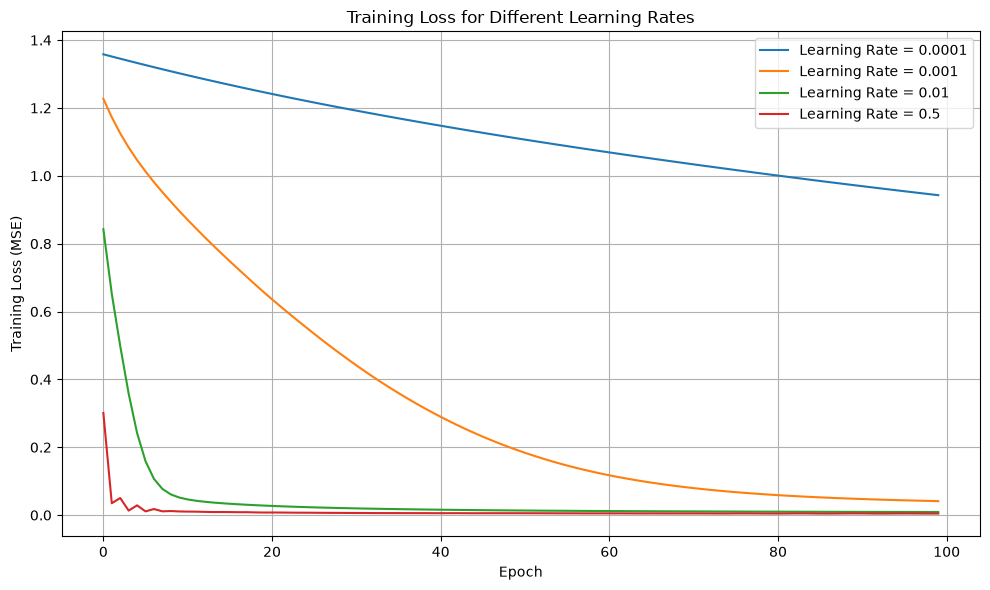

In [5]:
results_df = pd.DataFrame(results)

display(results_df)

plt.figure(figsize=(10, 6))

for learning_rate in learning_rates:

    plt.plot(
        histories[learning_rate].history["loss"],
        label=f"Learning Rate = {learning_rate}"
    )

plt.title("Training Loss for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()